# 5.4.3 随机游走中的漂移与扩散

## 学习目标与先修知识

能推导独立二值步长的均值与方差（variance），比较有偏与无偏游走，说明位置相关性、边界和连续极限（limit）的适用范围。

先修：期望（expectation）、方差、独立增量求和；上一节的过程与分布（distribution）区别。 [复习上一节](02-不变分布与长期收敛的条件.ipynb)。

## 具体问题

理想粒子平均位置一直为零，却越来越分散。静止的平均曲线隐藏了什么？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
increments=np.array([1,-1,1,1,-1])
positions=np.r_[0,np.cumsum(increments)]
display(Markdown(show_table(['步 n','位置 / L'],enumerate(positions))))

| 步 n | 位置 / L |
| --- | --- |
| 0 | 0 |
| 1 | 1 |
| 2 | 0 |
| 3 | 1 |
| 4 | 2 |
| 5 | 1 |

## 模型假设

一维无边界空间，从 0 出发，每周期独立向右 d=1 L 或向左 d，向右概率（probability） p 为 0.5 或 0.65；没有惯性、细胞交互或吸收边界。每种 p 使用 200 条独立路径，60 步；根种子 5403，子流按 p 再路径下标派生。

## 数学解释与推导

设增量 Z 为 +d 或 −d，P(Z=d)=p。由概率表求得 E[Z]=d(2p−1)、E[Z²]=d²，因此 Var(Z)=4d²p(1−p)。位置为 X[n]=ΣZ[j]，独立增量使
$$E[X_n]=nd(2p-1),\qquad\operatorname{Var}(X_n)=4nd^2p(1-p).$$
p=1/2 时平均为零，但标准差（standard deviation）为 d√n；单条路径仍不断移动。p=0 或 1 时完全确定，方差为零，有非零漂移。

位置之间不独立。若 m≤n，则 X[n]=X[m]+后续独立增量，故 Cov(X[m],X[n])=Var(X[m])。因此从一条长路径取许多时刻，并不等同于抽取许多独立粒子。

若每步时间 Δt，公平情形 Var(X(t))≈d²t/Δt，可定义扩散系数（diffusion coefficient） D=d²/(2Δt)，单位 L²/T，使 Var≈2Dt。要进一步取连续极限需要同时缩小 d 与 Δt 并保持该比例，本节不引入随机微积分。加入反射边界、吸收或持续方向后，原独立增量模型（model）可能失效，需重新写规则。

## 核心实现

把公式中的量和顺序写成可检查的计算。

In [3]:
def walk_moments(probability, step_size, steps):
    means = [n*step_size*(2*probability-1) for n in range(steps+1)]
    variances = [4*n*step_size**2*probability*(1-probability) for n in range(steps+1)]
    return means, variances

## 对照实验

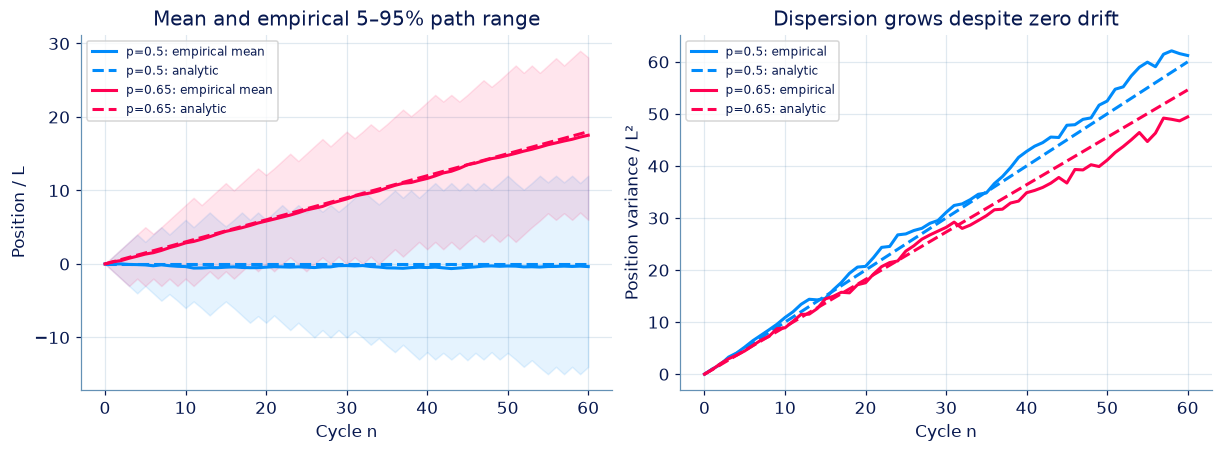

| p | 末均值 / L | 理论均值 / L | 末方差 / L² | 理论方差 / L² |
| --- | --- | --- | --- | --- |
| 0.5 | -0.36 | 0 | 61.2165 | 60 |
| 0.65 | 17.51 | 18 | 49.427 | 54.6 |

根种子 5403 ；每种 p 的路径数 200 ；PCG64；NumPy 2.5.3


In [4]:
probabilities=[.5,.65];repeats=200;steps=60;root_seed=5403
streams=np.random.SeedSequence(root_seed).spawn(400);n=np.arange(steps+1)
fig,axes=plt.subplots(1,2,figsize=(11,4));all_paths=[]
for j,p in enumerate(probabilities):
    paths=[]
    for b in range(repeats):
        rng=np.random.Generator(np.random.PCG64(streams[j*repeats+b]))
        increments=np.where(rng.random(steps)<p,1,-1)
        paths.append(np.r_[0,np.cumsum(increments)])
    paths=np.array(paths);all_paths.append(paths)
    mean,variance=walk_moments(p,1,steps);color=[BLUE,PINK][j]
    axes[0].plot(n,paths.mean(axis=0),color=color,label=f'p={p}: empirical mean')
    axes[0].plot(n,mean,color=color,ls='--',label=f'p={p}: analytic')
    lo,hi=np.quantile(paths,[.05,.95],axis=0)
    axes[0].fill_between(n,lo,hi,color=color,alpha=.1)
    axes[1].plot(n,paths.var(axis=0,ddof=1),color=color,label=f'p={p}: empirical')
    axes[1].plot(n,variance,color=color,ls='--',label=f'p={p}: analytic')
axes[0].set(xlabel='Cycle n',ylabel='Position / L',title='Mean and empirical 5–95% path range')
axes[1].set(xlabel='Cycle n',ylabel='Position variance / L²',title='Dispersion grows despite zero drift')
for ax in axes:ax.legend(fontsize=8)
plt.show()
display(Markdown(show_table(['p','末均值 / L','理论均值 / L','末方差 / L²','理论方差 / L²'],[(p,a[:,-1].mean(),walk_moments(p,1,steps)[0][-1],a[:,-1].var(ddof=1),walk_moments(p,1,steps)[1][-1]) for p,a in zip(probabilities,all_paths)])))
print('根种子',root_seed,'；每种 p 的路径数',repeats,'；PCG64；NumPy',np.__version__)

## 结果解释

公平游走的群体中心不漂移，阴影范围却变宽。有偏游走同时漂移和扩散。带是逐时刻路径分位摘要；不能把它当成平均曲线的误差带，后者随路径数增多会缩小。

### 独立核对

四步可枚举全部 16 条路径。终点等于 2 倍二项成功数减步数，独立提供均值、方差与四阶矩；四阶矩仅用于波动诊断，完整推导作为拓展。

In [5]:
import itertools
endpoints=[sum(signs) for signs in itertools.product([-1,1],repeat=4)]
mu,var=walk_moments(.5,1,4)
assert np.mean(endpoints)==mu[-1] and np.var(endpoints)==var[-1]
assert walk_moments(1,2,2)==([0,2,4],[0,0,0])
for p,paths in zip(probabilities,all_paths):
    mu,var=walk_moments(p,1,steps)
    assert abs(paths[:,-1].mean()-mu[-1])<5*np.sqrt(var[-1]/repeats)
    # Exact fourth central moment of a binomial endpoint gives variance-estimator variance.
    v=steps*p*(1-p);fourth=16*(3*v*v+v*(1-6*p*(1-p)))
    variance_sd=np.sqrt((fourth-(repeats-3)/(repeats-1)*var[-1]**2)/repeats)
    assert abs(paths[:,-1].var(ddof=1)-var[-1])<5*variance_sd
print('四步全枚举、确定边界及二项分布终点矩一致。')

四步全枚举、确定边界及二项分布终点矩一致。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/05-04-随机过程与马尔可夫模型/explore/)：改变一个条件，比较实现、分布与理论参照，再返回完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：随机游走的漂移与散布

从位置 0 出发，每步独立以 probability 向右走 step_size，否则向左走同样距离。计算各时刻理论均值与方差（variance）。

**函数与代码模板**

```python
def solve(
    probability: float,
    step_size: float,
    steps: int,
) -> tuple[list[float], list[float]]:
    # 依据题目规则计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `probability` | `float` | 向右概率（probability）。 | 1 |
| `step_size` | `float` | 每步长度。 | L |
| `steps` | `int` | 步数。 | 步 |

**返回值**

按以下顺序返回元组：(means, variances)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `means` | `list[float]` | 包含起点的理论位置均值。 | L |
| `variances` | `list[float]` | 包含起点的理论位置方差。 | L² |

**计算规则**

独立增量每步均值 d(2p−1)，方差 4d²p(1−p)；第 n 步的均值和方差分别乘 n。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 0≤probability≤1；0<step_size≤10；0≤steps≤100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| probability | 向右概率（probability）。 | 0.5 | 1 |
| step_size | 每步长度。 | 1 | L |
| steps | 步数。 | 3 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
probability = 0.5
step_size = 1
steps = 3

result = solve(probability, step_size, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| means | 包含起点的理论位置均值。 | [0.0, 0.0, 0.0, 0.0] | L |
| variances | 包含起点的理论位置方差。 | [0.0, 1.0, 2.0, 3.0] | L² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([0.0, 0.0, 0.0, 0.0],
                   [0.0, 1.0, 2.0, 3.0])
```

**样例解释**

公平游走均值 [0,0,0,0]，方差 [0,1,2,3]；平均不动不意味着每个个体不动。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：随机游走的漂移与散布](http://127.0.0.1:8000/chapters/05-04-%E9%9A%8F%E6%9C%BA%E8%BF%87%E7%A8%8B%E4%B8%8E%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p05-walk)

### 第 2 题 · 多项选择题：均值为零的群体是否静止

公平独立随机游走（random walk）从 0 出发。哪些成立？

- **A.** 理论平均位置始终为零。
- **B.** 位置方差（variance）随步数线性增加。
- **C.** 均方根位移与步数平方根成比例。
- **D.** 每条路径始终位于零。

[作答：均值为零的群体是否静止](http://127.0.0.1:8000/chapters/05-04-%E9%9A%8F%E6%9C%BA%E8%BF%87%E7%A8%8B%E4%B8%8E%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p05-walk-path)

### 第 3 题 · 单项选择题：加上反射边界还能照搬公式吗

原游走无边界；现在把位置限制在有限区间，触边时反射。哪项正确？

- **A.** 仅改图的横轴就足够。
- **B.** 反射永远不影响任何路径。
- **C.** 无边界的方差（variance） n*d² 必定适用于任意长时间。
- **D.** 边界改变增量依赖和分布（distribution），需重新建模或用有限链传播。

[作答：加上反射边界还能照搬公式吗](http://127.0.0.1:8000/chapters/05-04-%E9%9A%8F%E6%9C%BA%E8%BF%87%E7%A8%8B%E4%B8%8E%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p05-walk-boundary)

### 第 4 题 · 单项选择题：相邻位置与增量的独立性

X[n+1]=X[n]+Z[n]，Z 是独立零均值增量。哪项正确？

- **A.** 增量独立意味着每条路径没有记忆坐标。
- **B.** X[n] 与 X[n+1] 一定独立。
- **C.** Cov(X[n],X[n+1])=Var(X[n])。
- **D.** 所有位置方差（variance）相等。

[作答：相邻位置与增量的独立性](http://127.0.0.1:8000/chapters/05-04-%E9%9A%8F%E6%9C%BA%E8%BF%87%E7%A8%8B%E4%B8%8E%E9%A9%AC%E5%B0%94%E5%8F%AF%E5%A4%AB%E6%A8%A1%E5%9E%8B/practice/?question=p05-walk-independence)

**进一步阅读**

[MIT 6.041 讲义](https://ocw.mit.edu/courses/6-041-probabilistic-systems-analysis-and-applied-probability-fall-2010/pages/lecture-notes/)：第 7、13、19 讲：独立和、随机过程与极限。